# Setup

In [2]:
# Import core and specialist libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tqdm as notebook_tqdm

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import hdbscan, umap

# Configure plotting styles and disable warnings
# import warnings
# warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
# plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Setup complete.")

c:\Users\thuyl\Desktop\University\IAT461\IAT461-Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## EDA - Data Analysis

### Column Description

**FID:** FireID

**SRC_AGENCY:** Agency (province, territory, parks) from which the fire data has been obtained.

**FIRENAME:** Agency firename

**LATITUDE:** Latitude

**LONGITUDE:** Longitude

**REP_DATE:** Date of fire reported by individual agencies

**SIZE_HA:** Fire size in hectares

**CAUSE:** Cause of fire  
- U: Unknown cause
- L: Lightning caused fire
- H: Human caused fire
- H-PB: Prescribed burn (human caused)
- Re: Reburn

**PROTZONE:** Protection Zone as indicated by source agency. There is currently no official national standard that has been applied to this attribute.

**ECOZONE:** Ecodistrict associated with fire point location.

#### Load CSV

In [3]:
df = pd.read_csv('CANADA_WILDFIRES.csv')

df.head(10)

,FID,SRC_AGENCY,LATITUDE,LONGITUDE,REP_DATE,SIZE_HA,CAUSE,PROTZONE,ECOZ_NAME
0,0,BC,59.963,-128.172,1953-05-26,8.0,H,,Boreal Cordillera
1,1,BC,59.318,-132.172,1950-06-22,8.0,L,,Boreal Cordillera
2,2,BC,59.876,-131.922,1950-06-04,12949.9,H,,Boreal Cordillera
3,3,BC,59.760,-132.808,1951-07-15,241.1,H,,Boreal Cordillera
4,4,BC,59.434,-126.172,1952-06-12,1.2,H,,Boreal Cordillera
5,5,BC,59.963,-136.502,1951-08-01,194.2,H,,Boreal Cordillera
6,6,BC,59.597,-126.728,1952-08-11,0.6,H,,Boreal Cordillera
7,7,BC,57.463,-122.816,1950-06-14,2071.9,L,,Taiga Plain
8,8,BC,57.126,-122.762,1950-06-13,0.1,H,,Taiga Plain
9,9,BC,57.684,-121.925,1953-05-01,7834.7,H,,Taiga Plain


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 423831 entries, 0 to 423830
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   FID         423831 non-null  int64  
 1   SRC_AGENCY  423831 non-null  str    
 2   LATITUDE    423831 non-null  float64
 3   LONGITUDE   423831 non-null  float64
 4   REP_DATE    420118 non-null  str    
 5   SIZE_HA     423831 non-null  float64
 6   CAUSE       423590 non-null  str    
 7   PROTZONE    422821 non-null  str    
 8   ECOZ_NAME   423831 non-null  str    
dtypes: float64(3), int64(1), str(5)
memory usage: 42.2 MB


In [5]:
df.describe()

,FID,LATITUDE,LONGITUDE,SIZE_HA
count,423831.000000,423831.000000,423831.000000,4.238310e+05
mean,211915.000000,51.895936,-104.253547,3.162710e+02
std,122349.615308,4.467770,20.412661,5.617050e+03
min,0.000000,0.000000,-166.044000,0.000000e+00
25%,105957.500000,49.133700,-120.112350,1.000000e-01
50%,211915.000000,51.023000,-114.503000,1.000000e-01
75%,317872.500000,54.630289,-88.303603,1.000000e+00
max,423830.000000,70.000000,116.188000,1.050000e+06


### Unique entries for PROTZONE
As stated: "There is currently no official national standard that has been applied to this attribute."

Which means every agency does it differently and therefore this column will have many unique values with no convention.

In [6]:
unique_PROTZONE = df['PROTZONE'].unique()
print(unique_PROTZONE)
print()
print(df['PROTZONE'].value_counts(dropna=False))

<ArrowStringArray>
[                    ' ',                   'EXT',             'Intensive',
  'W (Observation Zone)',      'G (Low Priority)',     'R (High Priority)',
 'Y (Moderate Priority)',                     nan,                   'MOD',
                   'MON',                   'FUL',                   'MDP',
                   'SUP',                   'MNP',              'nordique',
              'Nordique',             'intensive',         'ActionCode: 1',
         'ActionCode: 2',          'FullResponse', 'Wilderness (forested)',
                  'Full',              'Critical',             'Strategic',
        'Wilderness FMZ',         'Stratigic FMZ',          'Critical FMZ',
        'Transition FMZ',              'Full FMZ',          'Transitional',
        'Initial Attack',       'Being Monitored',      'Sustained Action',
        'Limited Action',        'Delayed Action',             'Monitored',
             'Abandoned',     'Modified Response',         'Full Resp

In [7]:
print(unique_PROTZONE.tolist())

[' ', 'EXT', 'Intensive', 'W (Observation Zone)', 'G (Low Priority)', 'R (High Priority)', 'Y (Moderate Priority)', nan, 'MOD', 'MON', 'FUL', 'MDP', 'SUP', 'MNP', 'nordique', 'Nordique', 'intensive', 'ActionCode: 1', 'ActionCode: 2', 'FullResponse', 'Wilderness (forested)', 'Full', 'Critical', 'Strategic', 'Wilderness FMZ', 'Stratigic FMZ', 'Critical FMZ', 'Transition FMZ', 'Full FMZ', 'Transitional', 'Initial Attack', 'Being Monitored', 'Sustained Action', 'Limited Action', 'Delayed Action', 'Monitored', 'Abandoned', 'Modified Response', 'Full Response', 'Prescribed Fire', 'Monitored Response']


### Unique Entries for SRC_AGENCY

In [8]:
unique_AGENCY = df['SRC_AGENCY'].unique()
print(unique_AGENCY)
print()
print(df['SRC_AGENCY'].value_counts(dropna=False))

<ArrowStringArray>
[      'BC',       'AB',       'SK',       'MB',       'ON',       'QC',
       'NL',       'NB',       'NS',       'YT',       'NT',    'PC-NA',
    'PC-WB',    'PC-VU',    'PC-BA',    'PC-EI',    'PC-WP',    'PC-JA',
    'PC-PA',    'PC-GL',    'PC-KO',    'PC-RE',    'PC-BT',    'PC-YO',
    'PC-RM',    'PC-GF',    'PC-GR',    'PC-WL',    'PC-FR',    'PC-PU',
    'PC-KG',    'PC-LM',    'PC-CB',    'PC-PE',    'PC-BP',    'PC-TI',
    'PC-SL',    'PC-KE',    'PC-PP',    'PC-SY',    'PC-SE',    'PC-NC',
    'PC-KL', 'PC-RE-GL',    'PC-GM',    'PC-PR',    'PC-TN',    'PC-GI',
    'PC-FW',    'PC-FO',    'PC-GB',    'PC-LO',    'PC-RO',    'PC-FU',
    'PC-MM',    'PC-TH']
Length: 56, dtype: str

SRC_AGENCY
BC          149410
ON           63508
AB           62707
QC           43124
MB           27508
SK           25287
NT           14365
NB           11041
NS           10451
YT            8061
NL            4372
PC-WB         1961
PC-BA          353
PC-JA          25

### Graph Exploration

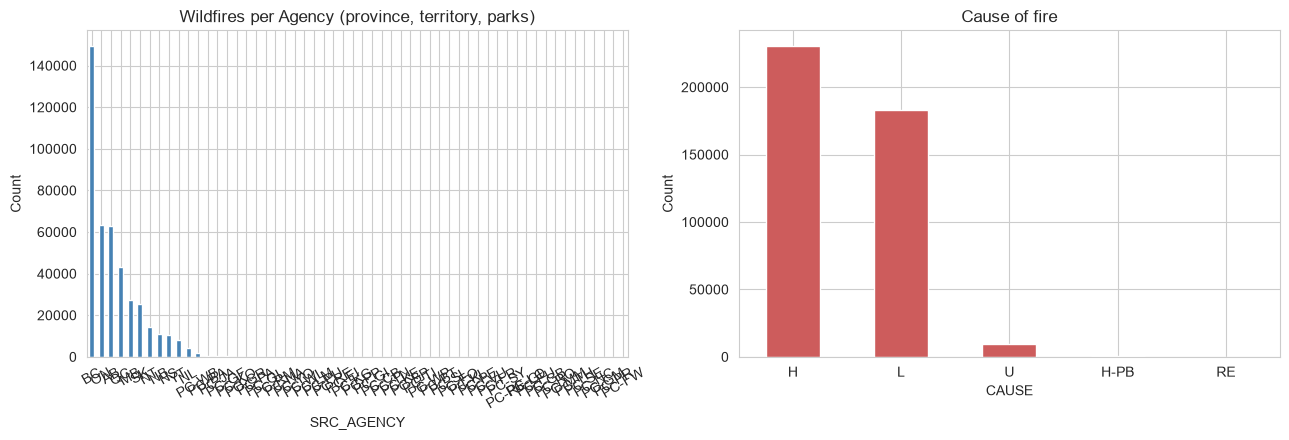

In [9]:
# create subplots with 1 row and 2 columns
fig, axes = plt.subplots(1,2, figsize=(13,4.5))

df["SRC_AGENCY"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Wildfires per Agency (province, territory, parks)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

df["CAUSE"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Cause of fire")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

# render plots
plt.tight_layout()
plt.show()

## Data-Cleaning

### 1. Covert dates to pandas datetime object

We can then use this datetime object to extract the month and then group them into seasons to determine when wildfires are most frequent.

In [10]:
df["REP_DATE"].head()

0    1953-05-26
1    1950-06-22
2    1950-06-04
3    1951-07-15
4    1952-06-12
Name: REP_DATE, dtype: str

In [11]:
df['DATE_OBJ'] = pd.to_datetime(df['REP_DATE'], format='%Y-%m-%d')
df["DATE_OBJ"].head()


0   1953-05-26
1   1950-06-22
2   1950-06-04
3   1951-07-15
4   1952-06-12
Name: DATE_OBJ, dtype: datetime64[us]

In [15]:
df['YEAR'] = df['DATE_OBJ'].dt.year
df['MONTH'] = df['DATE_OBJ'].dt.month
df['MONTH_NAME'] = pd.to_datetime(df['MONTH'], format='%m').dt.month_name().str[:3]
df.head(5)

,FID,SRC_AGENCY,LATITUDE,LONGITUDE,REP_DATE,SIZE_HA,CAUSE,PROTZONE,ECOZ_NAME,DATE_OBJ,YEAR,MONTH,MONTH_NAME
0,0,BC,59.963,-128.172,1953-05-26,8.0,H,,Boreal Cordillera,1953-05-26,1953.0,5.0,May
1,1,BC,59.318,-132.172,1950-06-22,8.0,L,,Boreal Cordillera,1950-06-22,1950.0,6.0,Jun
2,2,BC,59.876,-131.922,1950-06-04,12949.9,H,,Boreal Cordillera,1950-06-04,1950.0,6.0,Jun
3,3,BC,59.760,-132.808,1951-07-15,241.1,H,,Boreal Cordillera,1951-07-15,1951.0,7.0,Jul
4,4,BC,59.434,-126.172,1952-06-12,1.2,H,,Boreal Cordillera,1952-06-12,1952.0,6.0,Jun


### 2. Create `SEASONS` Column

In [ ]:
# cast to int
df['MONTH'] = df['MONTH'].astype(int)
df['YEAR'] = df['YEAR'].astype(int)

# dictionary
seasons_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

# mapping
df['SEASON'] = df['MONTH'].map(seasons_map)

df.head(5)